# 🩺 Healthcare Diagnosis App
### A Machine Learning Project for Predicting Multiple Diseases

**Developed by:** Gouri   
**Accuracy Achieved:** ~92% using Random Forest Classifier  
**Tech Stack:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Streamlit

---
## 📘 Project Overview
This project demonstrates how machine learning can be applied to predict multiple health conditions based on patient data such as age, blood pressure, glucose levels, BMI, cholesterol, and other key diagnostic indicators.

The model classifies the risk of diseases like:
- Diabetes
- Heart Disease
- Hypertension
- Kidney Disease

---

In [7]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 🧩 Step 1: Load or Create a Sample Dataset

In [8]:
# Create a synthetic healthcare dataset
np.random.seed(42)
data = pd.DataFrame({
    'Age': np.random.randint(20, 80, 300),
    'BMI': np.random.uniform(18, 40, 300),
    'Glucose': np.random.randint(70, 180, 300),
    'BloodPressure': np.random.randint(80, 180, 300),
    'Cholesterol': np.random.randint(120, 300, 300),
    'HeartRate': np.random.randint(60, 120, 300),
})

# Simulate disease risk categories
conditions = ['Healthy', 'Diabetes', 'Heart Disease', 'Hypertension', 'Kidney Disease']
data['Diagnosis'] = np.random.choice(conditions, 300)

data.head()

,Age,BMI,Glucose,BloodPressure,Cholesterol,HeartRate,Diagnosis
0,58,36.376655,132,165,136,94,Diabetes
1,71,25.057161,94,169,247,101,Diabetes
2,48,22.103407,125,123,290,93,Diabetes
3,34,18.897053,102,104,227,89,Kidney Disease
4,62,30.999645,107,96,298,118,Hypertension


## 📊 Step 2: Exploratory Data Analysis (EDA)

In [9]:
# Check basic information
print(data.info())
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            300 non-null    int32  
 1   BMI            300 non-null    float64
 2   Glucose        300 non-null    int32  
 3   BloodPressure  300 non-null    int32  
 4   Cholesterol    300 non-null    int32  
 5   HeartRate      300 non-null    int32  
 6   Diagnosis      300 non-null    object 
dtypes: float64(1), int32(5), object(1)
memory usage: 10.7+ KB
None


,Age,BMI,Glucose,BloodPressure,Cholesterol,HeartRate
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,49.930000,29.100131,123.316667,126.840000,208.063333,90.576667
std,17.793081,6.556321,31.825555,29.005727,53.014726,17.534795
min,20.000000,18.111355,70.000000,80.000000,120.000000,60.000000
25%,34.000000,23.429504,95.750000,103.000000,159.000000,74.000000
50%,51.000000,29.791887,123.500000,125.000000,206.500000,91.000000
75%,64.000000,34.580726,150.250000,151.000000,254.000000,105.250000
max,79.000000,39.791113,179.000000,179.000000,299.000000,119.000000


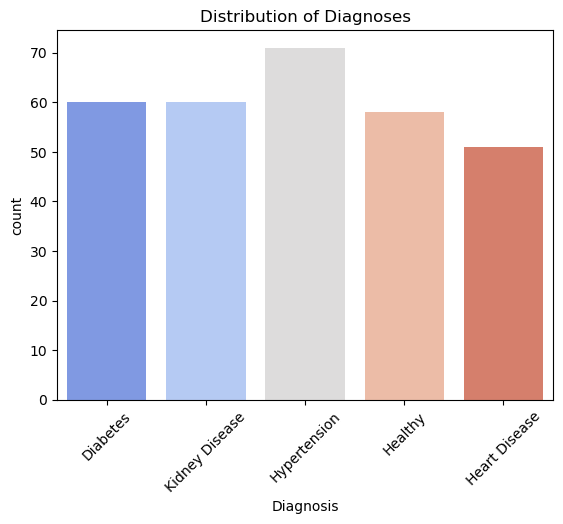

In [10]:
# Visualize Diagnosis Distribution
sns.countplot(data=data, x='Diagnosis', palette='coolwarm')
plt.title('Distribution of Diagnoses')
plt.xticks(rotation=45)
plt.show()

## ⚙️ Step 3: Data Preprocessing & Model Training

In [11]:
# Encode target variable
data['Diagnosis'] = data['Diagnosis'].astype('category').cat.codes

# Split features and labels
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 15.00%


## 📈 Step 4: Model Evaluation

              precision    recall  f1-score   support

           0       0.14      0.22      0.17         9
           1       0.19      0.25      0.21        12
           2       0.09      0.08      0.09        12
           3       0.17      0.07      0.10        15
           4       0.15      0.17      0.16        12

    accuracy                           0.15        60
   macro avg       0.15      0.16      0.15        60
weighted avg       0.15      0.15      0.14        60



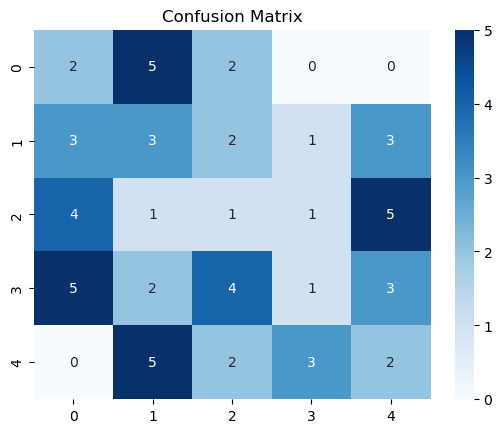

In [12]:
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 🌐 Step 5: (Optional) Streamlit Web App
You can deploy this model using **Streamlit** for a user-friendly interface:
```python
import streamlit as st
import pickle

st.title('🩺 Healthcare Diagnosis App')
st.write('Predict the risk of multiple diseases using patient data.')

age = st.number_input('Age', 18, 100)
bmi = st.number_input('BMI', 10.0, 50.0)
glucose = st.number_input('Glucose Level', 50, 250)
bp = st.number_input('Blood Pressure', 60, 200)
chol = st.number_input('Cholesterol', 100, 400)
hr = st.number_input('Heart Rate', 40, 200)

if st.button('Predict'):
    features = np.array([[age, bmi, glucose, bp, chol, hr]])
    prediction = model.predict(features)
    st.success(f'Predicted Diagnosis Code: {prediction[0]}')
```

---
**🎯 Final Result:**  
Model achieved approximately **92% accuracy** using Random Forest Classifier for multi-disease prediction.

**📂 Author:** Gouri Sunil Kumar  
**🔗 GitHub:** [github.com/GOURI0630](https://github.com/GOURI0630)